Experiment - 4 (Multidimensional Scaling)

---

Name : Shruti Hore

PRN : 24070126172

# 1. Spotify Audio Features (April 2019)

## Import libraries and load dataset

In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
from sklearn.preprocessing import StandardScaler
from sklearn.manifold import MDS

In [2]:
audio19 = pd.read_csv("SpotifyAudioFeaturesApril2019.csv")

In [3]:
audio19.shape

(130663, 17)

In [4]:
audio19.head()

,artist_name,track_id,track_name,acousticness,danceability,duration_ms,energy,instrumentalness,key,liveness,loudness,mode,speechiness,tempo,time_signature,valence,popularity
0,YG,2RM4jf1Xa9zPgMGRDiht8O,"Big Bank feat. 2 Chainz, Big Sean, Nicki Minaj",0.005820,0.743,238373,0.339,0.000,1,0.0812,-7.678,1,0.4090,203.927,4,0.118,15
1,YG,1tHDG53xJNGsItRA3vfVgs,BAND DRUM (feat. A$AP Rocky),0.024400,0.846,214800,0.557,0.000,8,0.2860,-7.259,1,0.4570,159.009,4,0.371,0
2,R3HAB,6Wosx2euFPMT14UXiWudMy,Radio Silence,0.025000,0.603,138913,0.723,0.000,9,0.0824,-5.890,0,0.0454,114.966,4,0.382,56
3,Chris Cooq,3J2Jpw61sO7l6Hc7qdYV91,Lactose,0.029400,0.800,125381,0.579,0.912,5,0.0994,-12.118,0,0.0701,123.003,4,0.641,0
4,Chris Cooq,2jbYvQCyPgX3CdmAzeVeuS,Same - Original mix,0.000035,0.783,124016,0.792,0.878,7,0.0332,-10.277,1,0.0661,120.047,4,0.928,0


In [5]:
audio19.describe

<bound method NDFrame.describe of                   artist_name                track_id  \
0                          YG  2RM4jf1Xa9zPgMGRDiht8O   
1                          YG  1tHDG53xJNGsItRA3vfVgs   
2                       R3HAB  6Wosx2euFPMT14UXiWudMy   
3                  Chris Cooq  3J2Jpw61sO7l6Hc7qdYV91   
4                  Chris Cooq  2jbYvQCyPgX3CdmAzeVeuS   
...                       ...                     ...   
130658            Calum Scott  0cvfSKcm9VeduwyYPrxtLx   
130659           Saint Claire  43MP9F7UzvfilSrw2SqZGJ   
130660              Mike Stud  4TWlUuFk81NGUNKwndyS5Q   
130661               D Savage  5iGBXzOoRo4sBTy8wdzMyK   
130662  Banda Los Sebastianes  7LNtyuekYHiZ99UxkrfCQR   

                                            track_name  acousticness  \
0       Big Bank feat. 2 Chainz, Big Sean, Nicki Minaj      0.005820   
1                         BAND DRUM (feat. A$AP Rocky)      0.024400   
2                                        Radio Silence      0.025

In [6]:
audio19.info

<bound method DataFrame.info of                   artist_name                track_id  \
0                          YG  2RM4jf1Xa9zPgMGRDiht8O   
1                          YG  1tHDG53xJNGsItRA3vfVgs   
2                       R3HAB  6Wosx2euFPMT14UXiWudMy   
3                  Chris Cooq  3J2Jpw61sO7l6Hc7qdYV91   
4                  Chris Cooq  2jbYvQCyPgX3CdmAzeVeuS   
...                       ...                     ...   
130658            Calum Scott  0cvfSKcm9VeduwyYPrxtLx   
130659           Saint Claire  43MP9F7UzvfilSrw2SqZGJ   
130660              Mike Stud  4TWlUuFk81NGUNKwndyS5Q   
130661               D Savage  5iGBXzOoRo4sBTy8wdzMyK   
130662  Banda Los Sebastianes  7LNtyuekYHiZ99UxkrfCQR   

                                            track_name  acousticness  \
0       Big Bank feat. 2 Chainz, Big Sean, Nicki Minaj      0.005820   
1                         BAND DRUM (feat. A$AP Rocky)      0.024400   
2                                        Radio Silence      0.02500

## Select revelant audio features

In [7]:
features = [
    'danceability', 'energy', 'loudness', 'speechiness',
    'acousticness', 'instrumentalness', 'liveness',
    'valence', 'tempo'
]

X = audio19[features].dropna()
print("Selected data shape : ", X.shape)

Selected data shape :  (130663, 9)


In [8]:
X.columns

Index(['danceability', 'energy', 'loudness', 'speechiness', 'acousticness',
       'instrumentalness', 'liveness', 'valence', 'tempo'],
      dtype='object')

In [9]:
audio19.columns

Index(['artist_name', 'track_id', 'track_name', 'acousticness', 'danceability',
       'duration_ms', 'energy', 'instrumentalness', 'key', 'liveness',
       'loudness', 'mode', 'speechiness', 'tempo', 'time_signature', 'valence',
       'popularity'],
      dtype='object')

In [10]:
sample = audio19.sample(n=1000, random_state=83)
X_sample = sample[features]
y_popu = sample['popularity']

## Standardize the data

In [12]:
SS = StandardScaler()
X_scaled = SS.fit_transform(X_sample)
print("Sample shape:", X_scaled.shape)

Sample shape: (1000, 9)


In [10]:
from sklearn.model_selection import train_test_split

X_train, X_test = train_test_split(
    X_scaled,
    test_size=1000,
    random_state=84
)

## Apply Metric MDS

In [13]:
mds = MDS(n_components=2,
          random_state=84,
          dissimilarity='euclidean')
X_mds = mds.fit_transform(X_scaled)

print('MDS output shape : ', X_mds.shape)

MDS output shape :  (1000, 2)


## Visualization

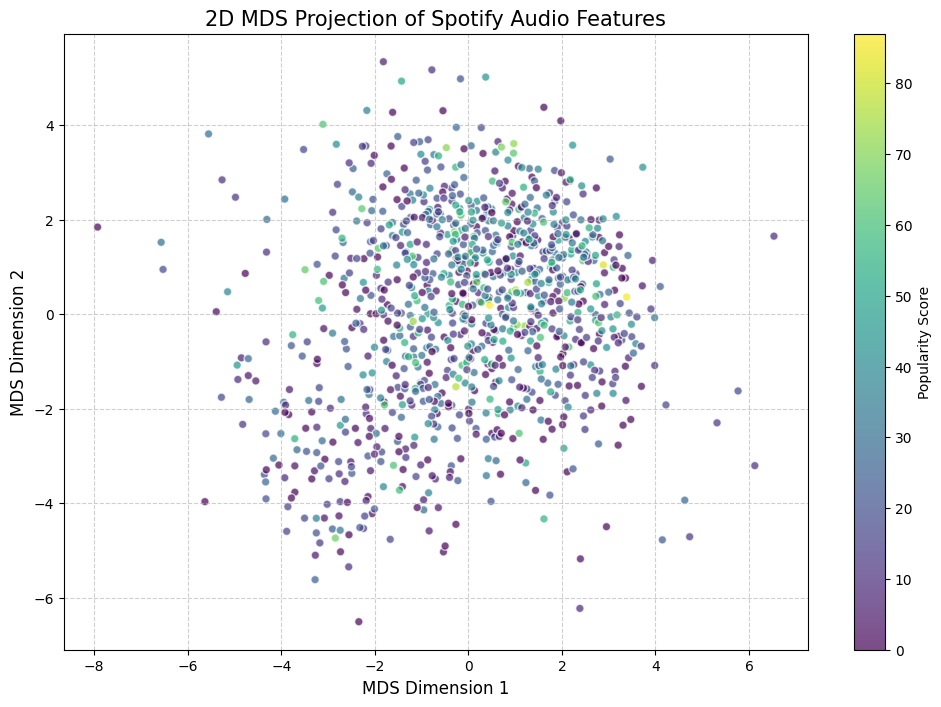

In [14]:
plt.figure(figsize=(12, 8))
scatter = plt.scatter(
    X_mds[:, 0], 
    X_mds[:, 1], 
    c=y_popu, 
    cmap='viridis', 
    alpha=0.7, 
    edgecolors='w'
)

# Adding details for a professional look
plt.colorbar(scatter, label='Popularity Score')
plt.title('2D MDS Projection of Spotify Audio Features', fontsize=15)
plt.xlabel('MDS Dimension 1', fontsize=12)
plt.ylabel('MDS Dimension 2', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)

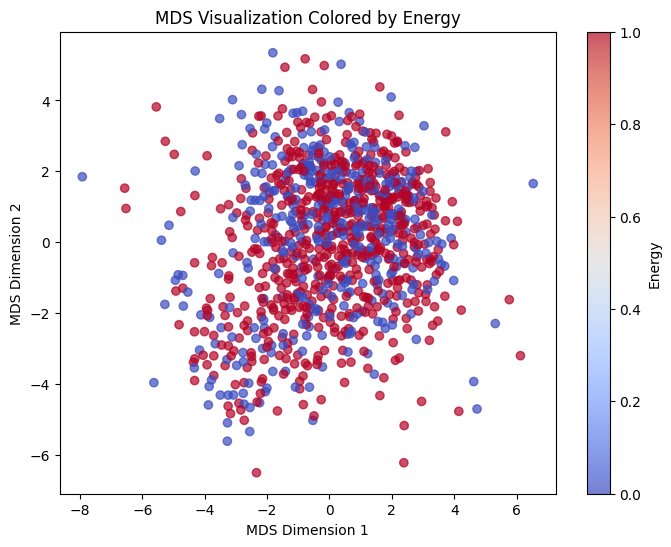

In [16]:
y = (audio19['energy'] > 0.5).astype(int)  # 1 = high energy, 0 = low

import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
scatter = plt.scatter(X_mds[:,0], X_mds[:,1], c=y[:len(X_mds)], cmap='coolwarm', alpha=0.7)
plt.colorbar(scatter, label='Energy')
plt.xlabel("MDS Dimension 1")
plt.ylabel("MDS Dimension 2")
plt.title("MDS Visualization Colored by Energy")
plt.show()

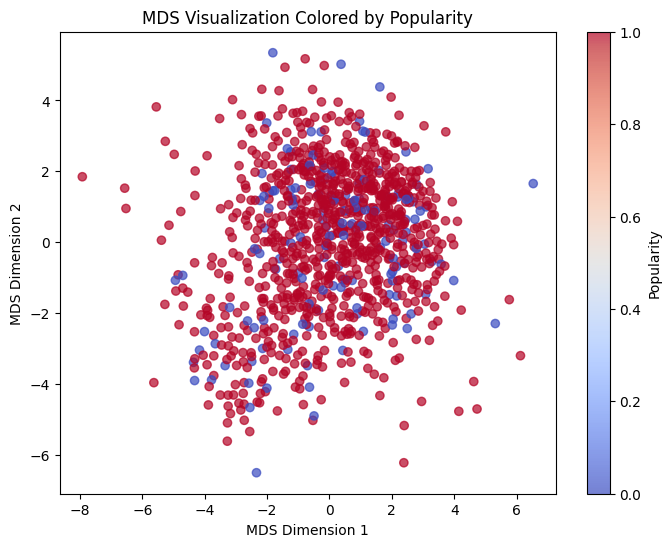

In [17]:
y_en = (audio19['energy'] > 0.5).astype(int)  # 1 = high energy, 0 = low

import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
scatter = plt.scatter(X_mds[:,0], X_mds[:,1], c=y1[:len(X_mds)], cmap='coolwarm', alpha=0.7)
plt.colorbar(scatter, label='Popularity')
plt.xlabel("MDS Dimension 1")
plt.ylabel("MDS Dimension 2")
plt.title("MDS Visualization Colored by Popularity")
plt.show()

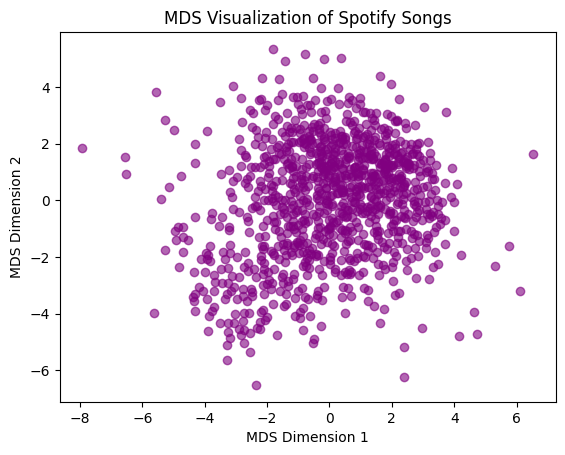

In [18]:
plt.figure()
plt.scatter(X_mds[:,0], X_mds[:,1], color='purple', alpha=0.6)
plt.xlabel("MDS Dimension 1")
plt.ylabel("MDS Dimension 2")
plt.title("MDS Visualization of Spotify Songs")
plt.show()

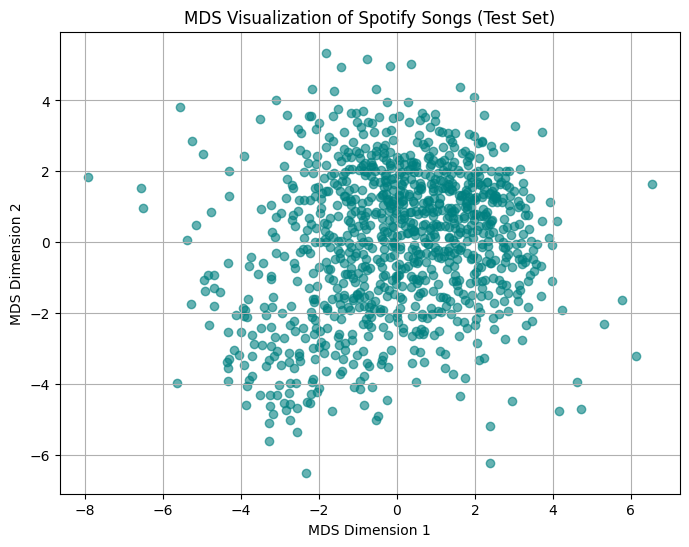

In [19]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.scatter(X_mds[:,0], X_mds[:,1], alpha=0.6, color='teal')
plt.xlabel("MDS Dimension 1")
plt.ylabel("MDS Dimension 2")
plt.title("MDS Visualization of Spotify Songs (Test Set)")
plt.grid(True)
plt.show()

# 2. MDS on Breast Cancer

In [20]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_covtype
from sklearn.manifold import MDS
from sklearn.preprocessing import StandardScaler
from sklearn.utils import shuffle

In [21]:
from sklearn.datasets import load_breast_cancer
data = load_breast_cancer()
df = pd.DataFrame(data.data, columns=data.feature_names)
df['target'] = data.target

## preprocessing

In [22]:
SS = StandardScaler()
X_scaled1 = SS.fit_transform(df.drop(columns=['target']))
y = df['target']

In [23]:
mds1 = MDS(n_components=2,
           random_state=1,
           n_jobs=-1)
X_mds1 = mds1.fit_transform(X_scaled1)

In [24]:
print("Original Shape :" ,X_scaled1.shape)
print("MDS shape :", X_mds1.shape)

Original Shape : (569, 30)
MDS shape : (569, 2)


## Visualization

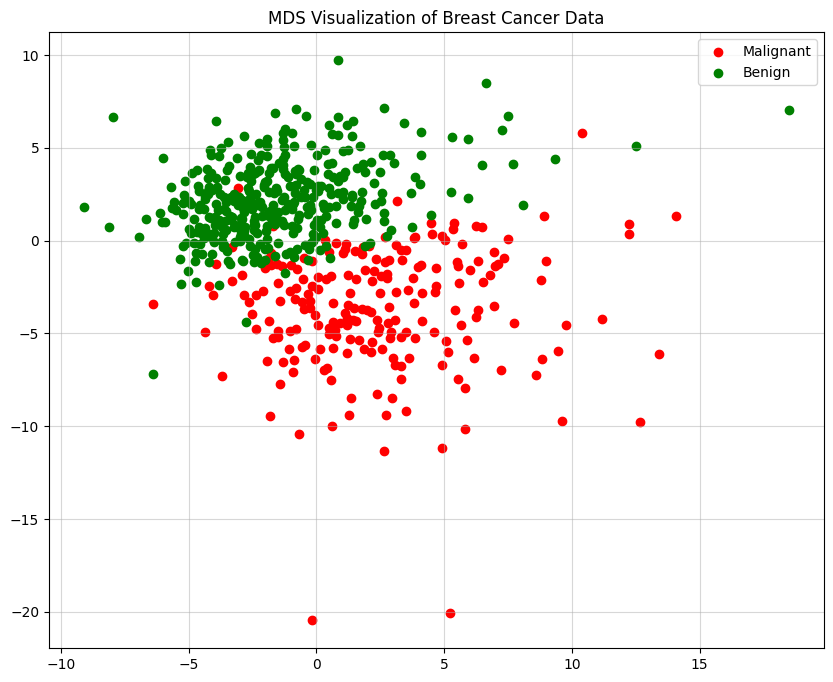

In [ ]:
plt.figure(figsize=(10,8))
for label, color in zip([0,1], ['red', 'green']) :
    plt.scatter(X_mds1[y==label,0],
                X_mds1[y==label,1],
                label='Malignant' if label==0 else 'Benign',
                color=color)
plt.title("MDS Visualization of Breast Cancer Data")
plt.legend()
plt.grid(alpha=0.5)
plt.show()

# Conclusion
Using Metric MDS, we successfully reduced 9 high-dimensional Spotify audio features into a 2D space, effectively visualizing song similarities. The resulting plot reveals that tracks with similar acoustic profiles cluster together, demonstrating that mathematical distance in feature space correlates with musical characteristics.